# Search-based Test Suite Generation (SuT: `calculate_shipping_fee`)

In this exercise, we'll implement a simple **search-based test suite generation** method that searches the input space and keeps tests that improve path coverage of `calculate_shipping_fee`.

In [8]:
def calculate_shipping_fee(
    order_total: int,
    weight_kg: float,
    distance_km: int,
    is_island: bool,
    membership: str,
    coupon_type: str,
) -> int:
    fee = 0

    if order_total < 40000:
        fee += 3000

    if weight_kg <= 5:
        fee += 0
    elif weight_kg <= 20:
        fee += 2000
    else:
        fee += 5000

    if distance_km <= 10:
        fee += 0
    elif distance_km <= 50:
        fee += 1000
    else:
        fee += 3000

    if is_island:
        fee += 4000

    if membership == "WOW":
        fee = fee // 2

    if coupon_type == "NEW_USER":
        fee -= 2000

    return max(fee, 0)

## Summary: test suite generation as a search problem

Test suite generation is reframed as **search over candidate suites** with **coverage as the objective**.

| Search / optimization | Test suite generation (this exercise) |
| --- | --- |
| **Search space** | All ordered suites of length $l$: each test case is `(order_total, weight_kg, distance_km, is_island, membership, coupon_type)`. |
| **Candidate solution** | One candidate test suite (a list of test-case tuples). |
| **Representation / encoding** | Fixed-length ordered list of mixed-type tuples (numeric + categorical). |
| **Objective function (fitness)** | Path coverage / behavioral diversity / path-distance proxy of `calculate_shipping_fee`. |
| **Optimization goal** | Maximize coverage (or maximize shaped fitness) under a fixed evaluation budget. |
| **Search operators** | Hill climbing: local mutation of one field in one test case. |

## Test Input Space as a Search Space

We define the shipping-fee input domain as a search space so test generation can be handled as optimization.


Each test input consists of six variables: three numeric (`order_total`, `weight_kg`, `distance_km`), one boolean (`is_island`), and two categorical (`membership`, `coupon_type`).

So the space is a **mixed domain** (continuous/discrete/categorical), which makes local search design more interesting than the triangle example.

In [9]:
# Pure random generator (baseline)
import random

def generate_random_test_input():
    order_total = random.randint(0, 120000)
    weight_kg = round(random.uniform(0, 50), 2)
    distance_km = random.randint(0, 200)
    is_island = random.choice([True, False])
    membership = random.choice(["NONE", "WOW"])
    coupon_type = random.choice(["NONE", "NEW_USER"])
    return order_total, weight_kg, distance_km, is_island, membership, coupon_type

The numeric dimensions are large and threshold-driven (`40000`, `5`, `20`, `10`, `50`), while categorical dimensions create branch toggles. Pure random often misses combinations that activate rare branch outcomes.

In [4]:
# 3D landscape view: (order_total, weight_kg, fee)
# Fixed settings: distance_km is constant, is_island is always False.
# Colors indicate membership x coupon_type combinations.

import importlib.util
import subprocess
import sys

print("[viz] checking plotly dependency...")
if importlib.util.find_spec("plotly") is None:
    print("[viz] plotly not found; installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "-q"])

import numpy as np
import pandas as pd
import plotly.express as px

# Fixed dimensions
distance_km_fixed = 30
is_island_fixed = False

# Evenly-spread integer grid for (order_total, weight_kg)
order_totals = np.arange(0, 120001, 2000, dtype=int)   # 0, 2000, ..., 120000
weights = np.arange(0, 51, 1, dtype=int)                # 0, 1, ..., 50

combinations = [
    ("NONE", "NONE"),
    ("NONE", "NEW_USER"),
    ("WOW", "NONE"),
    ("WOW", "NEW_USER"),
]

print(
    f"[viz] start data generation | order_points={len(order_totals)}, "
    f"weight_points={len(weights)}, combos={len(combinations)}"
)

rows = []
for membership, coupon_type in combinations:
    combo_name = f"{membership} x {coupon_type}"
    print(f"[viz] generating combo: {combo_name}")
    for order_total in order_totals:
        for weight_kg in weights:
            fee = calculate_shipping_fee(
                int(order_total),
                float(weight_kg),
                int(distance_km_fixed),
                bool(is_island_fixed),
                membership,
                coupon_type,
            )
            rows.append(
                {
                    "order_total": int(order_total),
                    "weight_kg": float(weight_kg),
                    "fee": int(fee),
                    "combo": combo_name,
                }
            )

print(f"[viz] data generation done | rows={len(rows)}")
print("[viz] building dataframe...")
df = pd.DataFrame(rows)

print("[viz] creating 3D figure...")
fig = px.scatter_3d(
    df,
    x="order_total",
    y="weight_kg",
    z="fee",
    color="combo",
    title=(
        "Shipping Fee Surface-like Scatter: order_total vs weight_kg vs fee "
        f"(distance_km={distance_km_fixed}, is_island={is_island_fixed})"
    ),
    opacity=0.7,
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(
    legend_title_text="membership x coupon_type",
    legend=dict(
        title=dict(font=dict(size=16)),
        font=dict(size=14),
        itemsizing="constant",
    ),
    scene=dict(
        xaxis_title="order_total",
        yaxis_title="weight_kg",
        zaxis_title="final fee",
    ),
    margin=dict(l=0, r=0, t=60, b=0),
)

print("[viz] rendering interactive figure...")
fig.show()
print("[viz] done.")






[viz] checking plotly dependency...
[viz] start data generation | order_points=61, weight_points=51, combos=4
[viz] generating combo: NONE x NONE
[viz] generating combo: NONE x NEW_USER
[viz] generating combo: WOW x NONE
[viz] generating combo: WOW x NEW_USER
[viz] data generation done | rows=12444
[viz] building dataframe...
[viz] creating 3D figure...
[viz] rendering interactive figure...


[viz] done.


## Representing a Test Suite as an **Individual** Solution

We represent a test suite as one candidate solution that can be evolved and compared during search.

In [11]:
# Example test suite whose length is 10
example_individual = [
    (10000, 3.0, 5, False, "NONE", "NONE"),
    (45000, 3.0, 5, False, "NONE", "NONE"),
    (10000, 12.0, 30, False, "NONE", "NONE"),
    (10000, 25.0, 80, False, "NONE", "NONE"),
    (10000, 3.0, 5, True, "NONE", "NONE"),
    (10000, 3.0, 5, False, "WOW", "NONE"),
    (10000, 3.0, 5, False, "NONE", "NEW_USER"),
    (10000, 25.0, 80, True, "WOW", "NEW_USER"),
    (39000, 5.0, 10, False, "NONE", "NONE"),
    (40000, 20.0, 50, False, "WOW", "NEW_USER"),
]

## Coverage as the Objective Functions

When the final objective is **maximizing path coverage**, we can still shape the fitness to improve search behavior.

Below are three complementary objectives:
1. Direct path coverage (ground-truth objective)
2. Input diversity — spread of test inputs in a normalized feature space (mean pairwise Euclidean distance)
3. Output diversity — spread of observed shipping fees (population variance of SuT outputs)


In [12]:
import os, sys

# exercises -> unit folder -> modules -> project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

print("Added to sys.path:", CODE_DIR)

from shipping_fee_instrumentation import PathCoverageTracker

path_tracker = PathCoverageTracker()
print("Path coverage tracker has been initialized.")


Added to sys.path: /workspace/modules/exercise_artifacts/code
Path coverage tracker has been initialized.


In [13]:
from typing import List, Tuple

TestCase = Tuple[int, float, int, bool, str, str]

def coverage_by_test_suite(test_suite: List[TestCase]) -> float:
    tracker = PathCoverageTracker()
    for test_case in test_suite:
        tracker.run_test(*test_case)
    percentage, _, _ = tracker.calculate_coverage()
    return percentage


### Fitness 1: Direct Path Coverage

This is the true objective: maximize aggregate path coverage of the suite.


In [14]:
def fitness_path_coverage(T: List[TestCase]) -> float:
    return coverage_by_test_suite(T)


In [15]:
score1 = fitness_path_coverage(example_individual)
print(f"Example individual's fitness 1 score (path coverage): {score1:.2f}")


Example individual's fitness 1 score (path coverage): 6.25


### Fitness 2: Input Diversity

Each test case is a mixed-type tuple. We map it to a **numeric feature vector** in \([0,1]^6\) by:

- scaling continuous fields by their generator ranges (`order_total` / 120000, `weight_kg` / 50, `distance_km` / 200),
- encoding booleans and categoricals as binary indicators (`is_island`, `WOW` membership, `NEW_USER` coupon).

**Fitness** is the **mean pairwise Euclidean distance** between those vectors across all tests in the suite. Larger values mean inputs are more spread out in the combined domain (standard dispersion measure for mixed tuples).


In [16]:
import math


def _test_case_feature_vector(tc: TestCase) -> Tuple[float, float, float, float, float, float]:
    order_total, weight_kg, distance_km, is_island, membership, coupon_type = tc
    return (
        order_total / 120_000.0,
        min(max(weight_kg, 0.0), 50.0) / 50.0,
        min(max(distance_km, 0), 200) / 200.0,
        1.0 if is_island else 0.0,
        1.0 if membership == "WOW" else 0.0,
        1.0 if coupon_type == "NEW_USER" else 0.0,
    )


def fitness_input_diversity(T: List[TestCase]) -> float:
    """Mean pairwise Euclidean distance in normalized input feature space."""
    n = len(T)
    if n < 2:
        return 0.0
    vecs = [_test_case_feature_vector(tc) for tc in T]
    total = 0.0
    pairs = 0
    for i in range(n):
        for j in range(i + 1, n):
            total += math.sqrt(
                sum((vecs[i][k] - vecs[j][k]) ** 2 for k in range(6))
            )
            pairs += 1
    return total / pairs


In [17]:
score2 = fitness_input_diversity(example_individual)
print(f"Example individual's fitness 2 score (input diversity): {score2:.4f}")


Example individual's fitness 2 score (input diversity): 1.1027


### Fitness 3: Output Diversity

Run `calculate_shipping_fee` on every test in the suite and collect integer fees.

**Fitness** is the **population variance** $\frac{1}{n}\sum_i (y_i - \bar{y})^2$ of those outputs. Maximizing it pushes the suite toward **many distinct behavioral outcomes** (different fee levels), which complements input diversity and path coverage.


In [20]:
import statistics


def fitness_output_diversity(T: List[TestCase]) -> float:
    """Population variance of SuT outputs (shipping fee integers)."""
    if len(T) < 2:
        return 0.0
    outs = [calculate_shipping_fee(*tc) for tc in T]
    return statistics.pvariance(outs)


In [21]:
score3 = fitness_output_diversity(example_individual)
print(f"Example individual's fitness 3 score (output diversity): {score3:.4f}")


Example individual's fitness 3 score (output diversity): 11310000.0000


## Search Algorithms

We'll run hill climbing and compare how fitness shaping affects path-coverage progress.


### Hill Climbing Algorithm (Greedy Algorithm)

Hill climbing starts from an initial test suite and repeatedly applies local mutations, keeping only improvements.

#### Mutation operator for individual test suite

One mutation changes one field of one test case (numeric perturbation or categorical flip).

In [22]:
# Random seed individual generation

def generate_random_seed_individual(length: int = 100) -> List[TestCase]:
    return [generate_random_test_input() for _ in range(length)]

random.seed(42)
seed_individual = generate_random_seed_individual(length=100)
print("Seed individual:")
for i, tc in enumerate(seed_individual, start=1):
    print(f"  {i:2d}: {tc}")

Seed individual:
   1: (83810, 5.57, 189, False, 'NONE', 'NONE')
   2: (18289, 36.82, 173, True, 'WOW', 'NONE')
   3: (3905, 4.68, 59, True, 'NONE', 'NEW_USER')
   4: (28893, 22.46, 71, True, 'NONE', 'NEW_USER')
   5: (44597, 13.89, 55, False, 'NONE', 'NONE')
   6: (49797, 4.84, 88, False, 'NONE', 'NEW_USER')
   7: (70284, 6.24, 96, True, 'WOW', 'NEW_USER')
   8: (75674, 9.61, 17, True, 'NONE', 'NEW_USER')
   9: (10458, 42.77, 25, False, 'WOW', 'NEW_USER')
  10: (83320, 41.71, 41, False, 'WOW', 'NONE')
  11: (87841, 13.35, 174, True, 'NONE', 'NONE')
  12: (21417, 23.11, 69, True, 'WOW', 'NONE')
  13: (30021, 41.09, 80, False, 'WOW', 'NONE')
  14: (27653, 45.66, 145, False, 'NONE', 'NEW_USER')
  15: (51856, 44.23, 164, False, 'NONE', 'NEW_USER')
  16: (18301, 12.33, 143, False, 'WOW', 'NEW_USER')
  17: (47447, 10.97, 35, False, 'NONE', 'NONE')
  18: (112866, 5.48, 160, True, 'WOW', 'NONE')
  19: (50432, 19.08, 119, False, 'NONE', 'NONE')
  20: (89353, 44.24, 192, False, 'WOW', 'NONE')
 

In [23]:
def mutation(T: List[TestCase]) -> List[TestCase]:
    mutated = [tuple(tc) for tc in T]

    case_idx = random.randrange(len(mutated))
    field_idx = random.randrange(6)
    old_case = list(mutated[case_idx])

    if field_idx == 0:  # order_total
        step = random.choice([-1000, -500, 500, 1000])
        old_case[0] = max(0, min(120000, old_case[0] + step))
    elif field_idx == 1:  # weight_kg
        step = random.choice([-1.0, -0.5, 0.5, 1.0])
        old_case[1] = round(max(0.0, min(50.0, old_case[1] + step)), 2)
    elif field_idx == 2:  # distance_km
        step = random.choice([-5, -1, 1, 5])
        old_case[2] = max(0, min(200, old_case[2] + step))
    elif field_idx == 3:  # is_island
        old_case[3] = not old_case[3]
    elif field_idx == 4:  # membership
        old_case[4] = "WOW" if old_case[4] != "WOW" else "NONE"
    else:  # coupon_type
        old_case[5] = "NEW_USER" if old_case[5] != "NEW_USER" else "NONE"

    mutated[case_idx] = tuple(old_case)
    return mutated

#### Run Hill-Climbing Algorithm

In [63]:
from typing import Callable, Dict

def hill_climbing(
    init_suite: List[TestCase],
    fitness_id: int = 1,
    k: int = 10,
    budget: int = 100,
    log_every: int = 10,
    verbose: bool = True,
):
    fitness_map: Dict[int, Callable[[List[TestCase]], float]] = {
        1: fitness_path_coverage,
        2: fitness_input_diversity,
        3: fitness_output_diversity,
    }
    if fitness_id not in fitness_map:
        raise ValueError("fitness_id must be one of {1, 2, 3}.")

    fitness_fn = fitness_map[fitness_id]

    current = [tuple(tc) for tc in init_suite]
    current_score = fitness_fn(current)
    best_suite = [tuple(tc) for tc in current]
    best_score = current_score

    history_scores = [best_score]
    history_suites = [[tuple(tc) for tc in best_suite]]

    if verbose:
        print(
            f"[HC] Start | fitness_id={fitness_id}, k={k}, budget={budget}, "
            f"initial_score={best_score:.4f}"
        )

    for step in range(1, budget + 1):
        best_neighbor = None
        best_neighbor_score = float("-inf")

        for _ in range(k):
            neighbor = mutation(current)
            score = fitness_fn(neighbor)
            if score > best_neighbor_score:
                best_neighbor = neighbor
                best_neighbor_score = score

        if best_neighbor is not None and best_neighbor_score > current_score:
            current = best_neighbor
            current_score = best_neighbor_score
            if current_score > best_score:
                best_suite = [tuple(tc) for tc in current]
                best_score = current_score

        history_scores.append(best_score)
        history_suites.append([tuple(tc) for tc in best_suite])

        if verbose and (step % log_every == 0 or step == budget):
            print(
                f"[HC] Step {step}/{budget} | "
                f"current={current_score:.4f}, best_so_far={best_score:.4f}"
            )

    return history_scores, history_suites, best_suite, best_score


[HC] Start | fitness_id=1, k=10, budget=100, initial_score=37.5000
[HC] Step 10/100 | current=41.6667, best_so_far=41.6667
[HC] Step 20/100 | current=42.3611, best_so_far=42.3611
[HC] Step 30/100 | current=42.3611, best_so_far=42.3611
[HC] Step 40/100 | current=42.3611, best_so_far=42.3611
[HC] Step 50/100 | current=42.3611, best_so_far=42.3611
[HC] Step 60/100 | current=42.3611, best_so_far=42.3611
[HC] Step 70/100 | current=42.3611, best_so_far=42.3611
[HC] Step 80/100 | current=42.3611, best_so_far=42.3611
[HC] Step 90/100 | current=42.3611, best_so_far=42.3611
[HC] Step 100/100 | current=42.3611, best_so_far=42.3611
[HC] Start | fitness_id=2, k=10, budget=100, initial_score=1.3585
[HC] Step 10/100 | current=1.3665, best_so_far=1.3665
[HC] Step 20/100 | current=1.3679, best_so_far=1.3679
[HC] Step 30/100 | current=1.3695, best_so_far=1.3695
[HC] Step 40/100 | current=1.3703, best_so_far=1.3703
[HC] Step 50/100 | current=1.3714, best_so_far=1.3714
[HC] Step 60/100 | current=1.3720, b

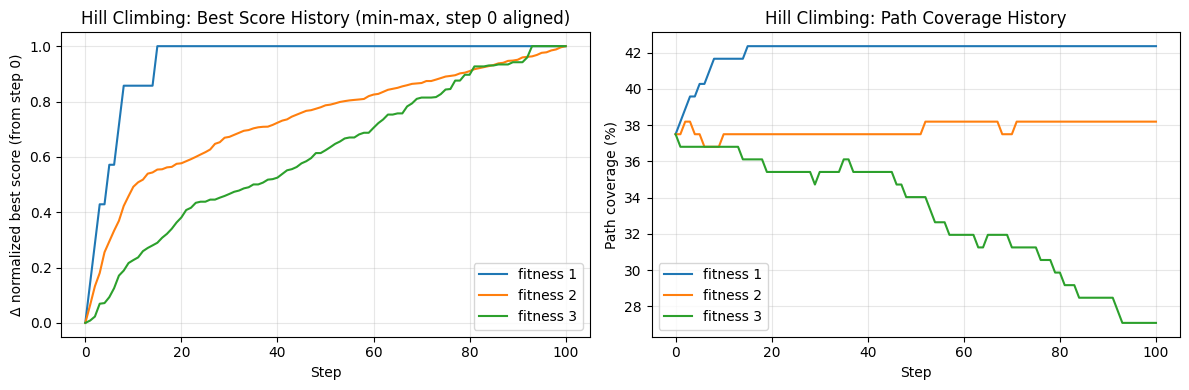

Final results by fitness choice:
- fitness 1: best_score=42.36, path_coverage=42.36%
- fitness 2: best_score=1.37, path_coverage=38.19%
- fitness 3: best_score=28008600.00, path_coverage=27.08%


In [64]:
import matplotlib.pyplot as plt

fitness_ids = [1, 2, 3]
colors = {
    1: "tab:blue",
    2: "tab:orange",
    3: "tab:green",
}

all_results = {}

for fitness_choice in fitness_ids:
    history_scores, history_suites, best_suite, best_score = hill_climbing(
        init_suite=seed_individual,
        fitness_id=fitness_choice,
    )
    history_path_coverage = [coverage_by_test_suite(suite) for suite in history_suites]
    final_path_coverage = coverage_by_test_suite(best_suite)

    all_results[fitness_choice] = {
        "history_scores": history_scores,
        "history_path_coverage": history_path_coverage,
        "best_suite": best_suite,
        "best_score": best_score,
        "final_path_coverage": final_path_coverage,
    }

def _minmax_scores_aligned(scores):
    """Per-run min-max to [0,1], then shift so step 0 is 0 for every fitness."""
    mn, mx = min(scores), max(scores)
    span = mx - mn
    if span <= 1e-15:
        return [0.0 for _ in scores]
    normed = [(s - mn) / span for s in scores]
    z0 = normed[0]
    return [x - z0 for x in normed]


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fid in fitness_ids:
    raw = all_results[fid]["history_scores"]
    aligned = _minmax_scores_aligned(raw)
    axes[0].plot(
        aligned,
        label=f"fitness {fid}",
        color=colors[fid],
    )
axes[0].set_title("Hill Climbing: Best Score History (min-max, step 0 aligned)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Δ normalized best score (from step 0)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for fid in fitness_ids:
    axes[1].plot(
        all_results[fid]["history_path_coverage"],
        label=f"fitness {fid}",
        color=colors[fid],
    )
axes[1].set_title("Hill Climbing: Path Coverage History")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Path coverage (%)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Final results by fitness choice:")
for fid in fitness_ids:
    best_score = all_results[fid]["best_score"]
    final_path_coverage = all_results[fid]["final_path_coverage"]
    print(f"- fitness {fid}: best_score={best_score:.2f}, path_coverage={final_path_coverage:.2f}%")


In [65]:
# (HC) Final best test suites: print each fitness table sequentially
import pandas as pd


def _suite_head_df(suite, n=10):
    cols = [
        "order_total",
        "weight_kg",
        "distance_km",
        "is_island",
        "membership",
        "coupon_type",
    ]
    df = pd.DataFrame(suite[:n], columns=cols)
    df["sut_output_fee"] = df.apply(
        lambda r: calculate_shipping_fee(
            int(r["order_total"]),
            float(r["weight_kg"]),
            int(r["distance_km"]),
            bool(r["is_island"]),
            str(r["membership"]),
            str(r["coupon_type"]),
        ),
        axis=1,
    )
    return df


for fid in [1, 2, 3]:
    print(f"\n[HC] fitness {fid} best suite (top 10)")
    display(_suite_head_df(all_results[fid]["best_suite"], n=10))


[HC] fitness 1 best suite (top 10)


,order_total,weight_kg,distance_km,is_island,membership,coupon_type,sut_output_fee
0,83810,5.57,189,False,NONE,NONE,5000
1,18289,36.82,173,True,WOW,NONE,7500
2,3905,4.68,59,True,NONE,NEW_USER,8000
3,28893,22.46,71,True,NONE,NEW_USER,13000
4,44597,13.89,55,False,NONE,NONE,5000
5,49797,4.84,88,False,NONE,NEW_USER,1000
6,70284,6.24,96,True,WOW,NEW_USER,2500
7,75674,9.61,17,True,NONE,NEW_USER,5000
8,10458,42.77,25,False,WOW,NEW_USER,2500
9,83320,41.71,41,False,WOW,NONE,3000



[HC] fitness 2 best suite (top 10)


,order_total,weight_kg,distance_km,is_island,membership,coupon_type,sut_output_fee
0,83810,4.57,195,False,NONE,NONE,3000
1,18289,36.82,173,True,WOW,NONE,7500
2,3905,3.68,59,True,NONE,NEW_USER,8000
3,28893,22.46,71,True,NONE,NEW_USER,13000
4,44597,13.89,50,True,NONE,NONE,7000
5,49797,4.84,88,False,NONE,NEW_USER,1000
6,70284,5.24,96,True,WOW,NEW_USER,2500
7,75674,9.61,17,True,WOW,NEW_USER,1500
8,10458,45.77,19,False,WOW,NEW_USER,2500
9,84320,41.71,31,False,WOW,NONE,3000



[HC] fitness 3 best suite (top 10)


,order_total,weight_kg,distance_km,is_island,membership,coupon_type,sut_output_fee
0,83810,5.57,189,False,NONE,NONE,5000
1,18289,36.82,173,True,NONE,NONE,15000
2,3905,4.68,59,True,WOW,NEW_USER,3000
3,28893,22.46,71,True,NONE,NONE,15000
4,44597,13.89,55,False,NONE,NONE,5000
5,49797,4.84,88,False,NONE,NEW_USER,1000
6,70284,6.24,96,False,WOW,NEW_USER,500
7,75674,9.61,17,False,NONE,NEW_USER,1000
8,10458,42.77,25,False,WOW,NEW_USER,2500
9,83320,41.71,41,False,WOW,NONE,3000


---

### Genetic Algorithm (Population-based Search)

A genetic algorithm evolves a population of test suites using selection, crossover, and mutation to discover higher-fitness solutions over generations.

#### Population

Population is the set of candidate individuals evolved at each generation.

In this exercise, the population size is 10 test suites, and each suite contains 100 test cases.

In [66]:
# Population initialization (GA building block)

def initialize_population(pop_size: int = 10, suite_len: int = 100):
    """Create initial population of test-suite individuals."""
    return [generate_random_seed_individual(length=suite_len) for _ in range(pop_size)]

# Example usage
population = initialize_population(pop_size=10, suite_len=100)
print(f"Initialized population size: {len(population)}")
print(f"Each individual length: {len(population[0])}")

Initialized population size: 10
Each individual length: 100


#### Mutation Operator

Mutation operator applies a small random change to one individual to explore nearby candidates.

In this exercise, we reuse the mutation function already implemented above to mutate one test suite individual.

#### Crossover Operator

Crossover operator combines two parent individuals by exchanging parts of their representations.

In this exercise, we pick one random cut index in the 100-test-case sequence and swap tails to return two offspring suites.

In [67]:
# Crossover building block

def crossover(parent1: List[TestCase], parent2: List[TestCase]):
    """One-point crossover for two test-suite individuals."""
    if len(parent1) != len(parent2):
        raise ValueError("Both parents must have the same suite length.")
    if len(parent1) < 2:
        return [tuple(tc) for tc in parent1], [tuple(tc) for tc in parent2]

    cut = random.randint(1, len(parent1) - 1)
    child1 = [tuple(tc) for tc in parent1[:cut]] + [tuple(tc) for tc in parent2[cut:]]
    child2 = [tuple(tc) for tc in parent2[:cut]] + [tuple(tc) for tc in parent1[cut:]]
    return child1, child2

# Example usage
p1 = generate_random_seed_individual(length=100)
p2 = generate_random_seed_individual(length=100)
c1, c2 = crossover(p1, p2)
print(f"Crossover done | len(child1)={len(c1)}, len(child2)={len(c2)}")

Crossover done | len(child1)=100, len(child2)=100


#### Selection Operator

Selection operator keeps fitter individuals and removes weaker ones to drive progress across generations.

In this exercise, we sort 10 suites by a chosen fitness score and keep only the top half (5 suites).

In [68]:
# Selection building block

def select_top_half(population, fitness_fn):
    """Sort population by fitness descending and keep top half."""
    scored = [(fitness_fn(ind), ind) for ind in population]
    scored.sort(key=lambda x: x[0], reverse=True)
    keep_n = max(1, len(population) // 2)
    selected = [ind for _, ind in scored[:keep_n]]
    return selected

# Example usage (selection only)
fitness_fn_example = fitness_path_coverage
selected = select_top_half(population, fitness_fn_example)
print(f"Selected survivors (top half): {len(selected)} / {len(population)}")

Selected survivors (top half): 5 / 10


#### Run GA Algorithm

In [69]:
# Define a function 'genetic_algorithm'
from typing import Callable, Dict


def genetic_algorithm(
    fitness_fn: Callable[[List[TestCase]], float],
    pop_size: int = 10,
    suite_len: int = 100,
    max_epoch: int = 100,
    crossover_fraction: float = 0.5,
    mutation_fraction: float = 0.5,
    seed: int = 42,
    log_every: int = 10,
    verbose: bool = True,
):
    """Run a simple GA and track best survivor history per epoch.

    Epoch order:
    1) selection -> 2) record -> 3) refill -> 4) crossover -> 5) mutation
    """
    if not (0.0 <= crossover_fraction <= 1.0):
        raise ValueError("crossover_fraction must be in [0, 1].")
    if not (0.0 <= mutation_fraction <= 1.0):
        raise ValueError("mutation_fraction must be in [0, 1].")

    random.seed(seed)
    population = initialize_population(pop_size=pop_size, suite_len=suite_len)

    if verbose:
        print(
            f"[GA] Start | pop_size={pop_size}, suite_len={suite_len}, "
            f"max_epoch={max_epoch}, crossover_fraction={crossover_fraction}, "
            f"mutation_fraction={mutation_fraction}"
        )

    score_history = []
    path_cov_history = []

    # Generation 0: same seeded population ⇒ same bests for every fitness_fn.
    score_history.append(max(fitness_fn(ind) for ind in population))
    path_cov_history.append(max(coverage_by_test_suite(ind) for ind in population))

    best_overall = None
    best_overall_score = float("-inf")

    for epoch in range(1, max_epoch + 1):
        # 1) Selection: keep top half
        survivors = select_top_half(population, fitness_fn)

        # 2) Record best from survivors
        scored_survivors = [(fitness_fn(ind), ind) for ind in survivors]
        scored_survivors.sort(key=lambda x: x[0], reverse=True)
        epoch_best_score, epoch_best_ind = scored_survivors[0]
        epoch_best_cov = coverage_by_test_suite(epoch_best_ind)

        if epoch_best_score > best_overall_score:
            best_overall_score = epoch_best_score
            best_overall = [tuple(tc) for tc in epoch_best_ind]

        # Record best-so-far history (monotonic)
        score_history.append(best_overall_score)
        path_cov_history.append(coverage_by_test_suite(best_overall))

        # 3) Refill dead half with new random individuals
        refill_n = pop_size - len(survivors)
        refilled = initialize_population(pop_size=refill_n, suite_len=suite_len)

        # Base next generation before variation
        next_generation = [[tuple(tc) for tc in ind] for ind in (survivors + refilled)]

        # 4) Crossover on random fraction of population
        n_cross = int(pop_size * crossover_fraction)
        if n_cross % 2 == 1:
            n_cross -= 1  # make it even for pairing
        if n_cross >= 2:
            cross_indices = random.sample(range(pop_size), n_cross)
            random.shuffle(cross_indices)
            for i in range(0, n_cross, 2):
                idx1 = cross_indices[i]
                idx2 = cross_indices[i + 1]
                c1, c2 = crossover(next_generation[idx1], next_generation[idx2])
                next_generation[idx1] = c1
                next_generation[idx2] = c2

        # 5) Mutation on random fraction of population
        n_mut = int(pop_size * mutation_fraction)
        if n_mut > 0:
            mut_indices = random.sample(range(pop_size), n_mut)
            for idx in mut_indices:
                next_generation[idx] = mutation(next_generation[idx])

        population = next_generation

        if verbose and (epoch % log_every == 0 or epoch == max_epoch):
            print(
                f"[GA] Epoch {epoch}/{max_epoch} | "
                f"epoch_best_score={epoch_best_score:.4f}, "
                f"best_so_far_score={best_overall_score:.4f}, "
                f"best_so_far_path_cov={coverage_by_test_suite(best_overall):.2f}%"
            )

    return {
        "score_history": score_history,
        "path_cov_history": path_cov_history,
        "best_suite": best_overall,
        "best_score": best_overall_score,
        "best_path_cov": coverage_by_test_suite(best_overall),
    }




[GA] Start | pop_size=10, suite_len=100, max_epoch=100, crossover_fraction=0.5, mutation_fraction=0.5
[GA] Epoch 10/100 | epoch_best_score=42.3611, best_so_far_score=42.3611, best_so_far_path_cov=42.36%
[GA] Epoch 20/100 | epoch_best_score=40.2778, best_so_far_score=42.3611, best_so_far_path_cov=42.36%
[GA] Epoch 30/100 | epoch_best_score=41.6667, best_so_far_score=42.3611, best_so_far_path_cov=42.36%
[GA] Epoch 40/100 | epoch_best_score=40.9722, best_so_far_score=42.3611, best_so_far_path_cov=42.36%
[GA] Epoch 50/100 | epoch_best_score=41.6667, best_so_far_score=43.0556, best_so_far_path_cov=43.06%
[GA] Epoch 60/100 | epoch_best_score=42.3611, best_so_far_score=43.7500, best_so_far_path_cov=43.75%
[GA] Epoch 70/100 | epoch_best_score=43.7500, best_so_far_score=44.4444, best_so_far_path_cov=44.44%
[GA] Epoch 80/100 | epoch_best_score=47.2222, best_so_far_score=47.2222, best_so_far_path_cov=47.22%
[GA] Epoch 90/100 | epoch_best_score=45.8333, best_so_far_score=47.2222, best_so_far_path_

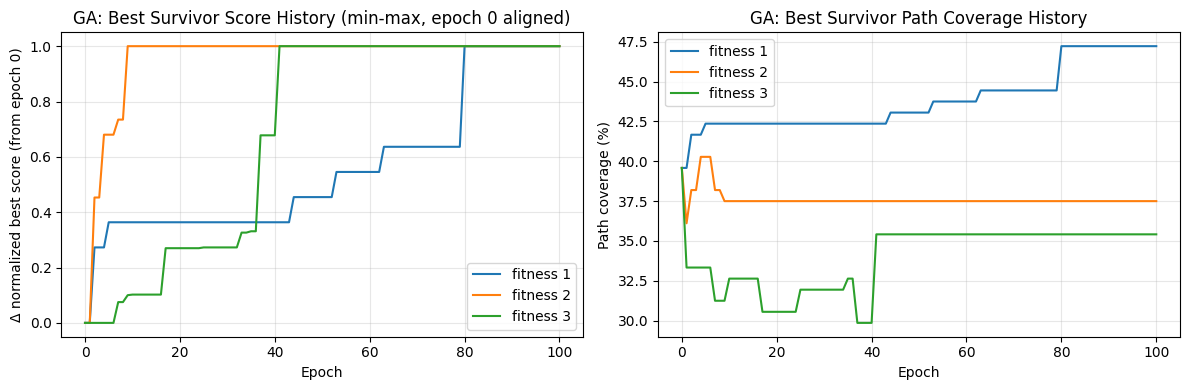

Final GA results (epoch=100):
- fitness 1: best_score=47.2222, best_path_coverage=47.22%
- fitness 2: best_score=1.4016, best_path_coverage=37.50%
- fitness 3: best_score=22551400.0000, best_path_coverage=35.42%


In [70]:
import matplotlib.pyplot as plt

# Run GA algorithm with 3 fitness functions
# Plot the results
fitness_map: Dict[int, Callable[[List[TestCase]], float]] = {
    1: fitness_path_coverage,
    2: fitness_input_diversity,
    3: fitness_output_diversity,
}

colors = {
    1: "tab:blue",
    2: "tab:orange",
    3: "tab:green",
}

all_ga_results = {}
for fid, ffn in fitness_map.items():
    all_ga_results[fid] = genetic_algorithm(
        fitness_fn=ffn,
        pop_size=10,
        suite_len=100,
        max_epoch=100,
        seed=42,
    )

def _minmax_scores_aligned(scores):
    """Per-run min-max to [0,1], then shift so epoch 0 is 0 for every fitness."""
    mn, mx = min(scores), max(scores)
    span = mx - mn
    if span <= 1e-15:
        return [0.0 for _ in scores]
    normed = [(s - mn) / span for s in scores]
    z0 = normed[0]
    return [x - z0 for x in normed]


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fid in [1, 2, 3]:
    raw = all_ga_results[fid]["score_history"]
    aligned = _minmax_scores_aligned(raw)
    axes[0].plot(
        aligned,
        label=f"fitness {fid}",
        color=colors[fid],
    )
axes[0].set_title("GA: Best Survivor Score History (min-max, epoch 0 aligned)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Δ normalized best score (from epoch 0)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for fid in [1, 2, 3]:
    axes[1].plot(
        all_ga_results[fid]["path_cov_history"],
        label=f"fitness {fid}",
        color=colors[fid],
    )
axes[1].set_title("GA: Best Survivor Path Coverage History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Path coverage (%)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Final GA results (epoch=100):")
for fid in [1, 2, 3]:
    r = all_ga_results[fid]
    print(
        f"- fitness {fid}: best_score={r['best_score']:.4f}, "
        f"best_path_coverage={r['best_path_cov']:.2f}%"
    )


In [71]:
# (GA) Final best test suites: print each fitness table sequentially
import pandas as pd


def _suite_head_df(suite, n=10):
    cols = [
        "order_total",
        "weight_kg",
        "distance_km",
        "is_island",
        "membership",
        "coupon_type",
    ]
    df = pd.DataFrame(suite[:n], columns=cols)
    df["sut_output_fee"] = df.apply(
        lambda r: calculate_shipping_fee(
            int(r["order_total"]),
            float(r["weight_kg"]),
            int(r["distance_km"]),
            bool(r["is_island"]),
            str(r["membership"]),
            str(r["coupon_type"]),
        ),
        axis=1,
    )
    return df


for fid in [1, 2, 3]:
    print(f"\n[GA] fitness {fid} best suite (top 10)")
    display(_suite_head_df(all_ga_results[fid]["best_suite"], n=10))


[GA] fitness 1 best suite (top 10)


,order_total,weight_kg,distance_km,is_island,membership,coupon_type,sut_output_fee
0,111354,41.34,46,False,WOW,NEW_USER,1000
1,82285,6.69,96,False,NONE,NONE,5000
2,5987,37.04,120,True,NONE,NEW_USER,13000
3,39183,1.72,128,False,WOW,NEW_USER,1000
4,101648,4.15,129,True,NONE,NONE,7000
5,88751,35.71,135,False,NONE,NEW_USER,6000
6,106826,6.79,71,False,WOW,NONE,2500
7,86524,46.87,173,True,WOW,NEW_USER,4000
8,11283,49.03,29,False,WOW,NEW_USER,2500
9,64335,37.70,97,True,NONE,NONE,12000



[GA] fitness 2 best suite (top 10)


,order_total,weight_kg,distance_km,is_island,membership,coupon_type,sut_output_fee
0,53449,38.68,161,True,WOW,NEW_USER,4000
1,82179,7.18,186,False,NONE,NEW_USER,3000
2,35405,0.84,126,False,WOW,NEW_USER,1000
3,51214,8.12,182,False,NONE,NEW_USER,3000
4,100003,43.15,171,True,NONE,NEW_USER,10000
5,2550,27.77,23,False,WOW,NEW_USER,2500
6,6251,49.10,144,True,WOW,NONE,7500
7,52072,46.83,172,False,NONE,NONE,8000
8,26009,10.13,59,True,NONE,NEW_USER,10000
9,46907,35.75,43,True,WOW,NEW_USER,3000



[GA] fitness 3 best suite (top 10)


,order_total,weight_kg,distance_km,is_island,membership,coupon_type,sut_output_fee
0,29763,34.49,159,True,NONE,NONE,15000
1,26151,31.26,157,True,NONE,NONE,15000
2,103572,47.96,85,True,WOW,NONE,6000
3,110969,26.29,180,False,NONE,NONE,8000
4,28085,31.97,90,True,NONE,NONE,15000
5,3256,31.61,146,True,NONE,NONE,15000
6,60108,0.09,152,False,NONE,NEW_USER,1000
7,32075,12.05,144,True,NONE,NONE,12000
8,118200,42.04,39,True,NONE,NEW_USER,8000
9,21366,6.00,68,True,NONE,NEW_USER,10000


## Search Results and Discussion

Analyze which fitness function gives the best path coverage for the same budget and why.
